# Boo Who? · Phase 4: clear monster rules for a Guess Who game

Version 2 flipped cards with neural network odds. The model was right, but players could not see **why** a card went down, so guessing felt random.

Here we turn the data into **simple rules a player can read**, like Guess Who:

1. Pick the questions that actually separate the monsters.
2. Cut each clue into 4 plain levels (for rot: none, little, some, lots).
3. For each monster, keep the levels that at least 15% of that monster has. That is the monster's rule.
4. Check on the 7,500 held-out monsters how often the rules leave exactly one card.

**Inputs:** `../data/clean/train_clean.csv`, `../web/data/monsters.json` · **Outputs:** `../web/data/tells.json`, `../reports/figures/rule_board.png`, `../reports/figures/question_value.png`

In [1]:
import json, itertools
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mutual_info_score

CLEAN = Path('../data/clean'); WEB = Path('../web/data'); FIGS = Path('../reports/figures')
CLASSES = ['Zombie', 'Witch', 'Ghost', 'Vampire', 'Mummy']
COLORS = ['green', 'grey', 'purple', 'white']
FIELD = {'rot': 'rottingFleshPct', 'blood': 'bloodCoverage', 'height': 'height', 'aura': 'aura', 'hair': 'hairLength'}
SEED, EPS = 42, 0.15

data = pd.read_csv(CLEAN / 'train_clean.csv')
data['color'] = data[[f'color_{c}' for c in COLORS]].values.argmax(1)
idx_tr, _ = train_test_split(np.arange(len(data)), test_size=0.2, stratify=data['class'], random_state=SEED)   # same split as notebooks 02 and 03
train = data.iloc[idx_tr].reset_index(drop=True)

game = pd.DataFrame(json.loads((WEB / 'monsters.json').read_text()))       # the 7,500 held-out monsters the game uses
game['color'] = game['color'].map(COLORS.index)
print(len(train), 'monsters to learn the rules from,', len(game), 'held-out monsters to test them on')

29997 monsters to learn the rules from, 7500 held-out monsters to test them on


## 1. Which questions are worth asking?

Mutual information measures how much knowing a clue (cut into 4 even groups) tells us about the monster. Higher is better.

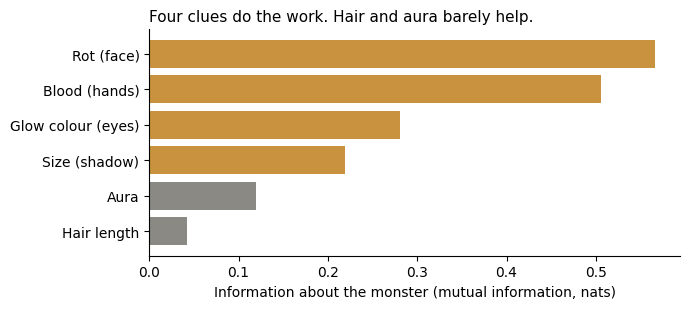

rot       0.566
blood     0.506
color     0.281
height    0.219
aura      0.120
hair      0.043
dtype: float64

In [2]:
def quartile_bins(s): return pd.qcut(s, 4, labels=False, duplicates='drop')
value = {q: mutual_info_score(train['class'], quartile_bins(train[f])) for q, f in FIELD.items()}
value['color'] = mutual_info_score(train['class'], train['color'])
value = pd.Series(value).sort_values(ascending=False)
names = {'rot': 'Rot (face)', 'blood': 'Blood (hands)', 'height': 'Size (shadow)', 'color': 'Glow colour (eyes)', 'aura': 'Aura', 'hair': 'Hair length'}

fig, ax = plt.subplots(figsize=(7, 3.2))
bars = ax.barh([names[k] for k in value.index][::-1], value.values[::-1], color=['#8a8984' if k in ('aura', 'hair') else '#c8923f' for k in value.index][::-1])
ax.set_xlabel('Information about the monster (mutual information, nats)'); ax.spines[['top', 'right']].set_visible(False)
ax.set_title('Four clues do the work. Hair and aura barely help.', loc='left', fontsize=11)
fig.tight_layout(); fig.savefig(FIGS / 'question_value.png', dpi=150); plt.show()
value.round(3)

Rot, blood, size and glow colour carry almost all the information. Hair length is nearly the same for every monster and aura only hints at Ghosts, so the game drops those two questions. Four questions, each with a clear answer.

## 2. Levels and rules

A level is a range, for example rot "lots" means more than 28%. A monster's rule for a question is the set of levels that at least 15% of that monster's training examples fall in. A monster **follows the rules** when every one of its answers is in its own rule. We search the cut points that make the rules both common (most monsters follow them) and sharp (one card left after the 4 questions).

In [3]:
QUESTIONS = ['rot', 'blood', 'height', 'color']

def levels(df, cuts):
    out = {q: np.digitize(df[FIELD[q]].values, cuts[q]) for q in QUESTIONS if q != 'color'}
    out['color'] = df['color'].values
    return out

def learn_rules(cuts):
    L = levels(train, cuts); y = train['class'].values; rules = {}
    for c in CLASSES:
        m = y == c
        rules[c] = {q: sorted(np.where(np.bincount(L[q][m], minlength=4) / m.sum() >= EPS)[0].tolist()) for q in QUESTIONS}
    return rules

def test_rules(rules, cuts, df=game):
    L = levels(df, cuts); y = df['class'].values
    fits = {c: np.all([np.isin(L[q], rules[c][q]) for q in QUESTIONS], axis=0) for c in CLASSES}   # would this card stay up?
    follows = np.array([fits[c][i] for i, c in enumerate(y)])
    cards_left = np.sum([fits[c] for c in CLASSES], axis=0)
    return {'follow': follows.mean(), 'one_left': (cards_left[follows] == 1).mean(), 'cards_left': cards_left[follows].mean(),
            'worst_class_follow': min(follows[y == c].mean() for c in CLASSES)}, follows, fits

best = None
for r in itertools.product([10, 12, 14], [18, 20], [26, 28]):
    for b in itertools.product([6, 8, 10], [14, 16, 18], [24, 26]):
        for h in itertools.product([54, 56, 58], [61, 62, 63], [65, 66, 67]):
            cuts = {'rot': list(r), 'blood': list(b), 'height': list(h)}
            s, _, _ = test_rules(learn_rules(cuts), cuts, train)                     # choose on training data only
            score = 0.5 * s['one_left'] + 0.5 * s['follow'] + 0.3 * s['worst_class_follow']
            if best is None or score > best[0]: best = (score, cuts)
CUTS = best[1]; RULES = learn_rules(CUTS)
print('cut points:', CUTS)

cut points: {'rot': [10, 18, 28], 'blood': [8, 18, 24], 'height': [58, 62, 65]}


In [4]:
stats, follows, fits = test_rules(RULES, CUTS)
print(f"On the held-out monsters: {stats['follow']:.1%} follow their monster's rules.")
print(f"For those, the 4 answers leave exactly one card {stats['one_left']:.1%} of the time ({stats['cards_left']:.2f} cards on average).")
pd.Series({c: follows[game['class'].values == c].mean() for c in CLASSES}, name='follow the rules').round(3)

On the held-out monsters: 71.6% follow their monster's rules.
For those, the 4 answers leave exactly one card 90.7% of the time (1.09 cards on average).


Zombie     0.744
Witch      0.658
Ghost      0.630
Vampire    0.804
Mummy      0.719
Name: follow the rules, dtype: float64

## 3. The rule board (what the cards show)

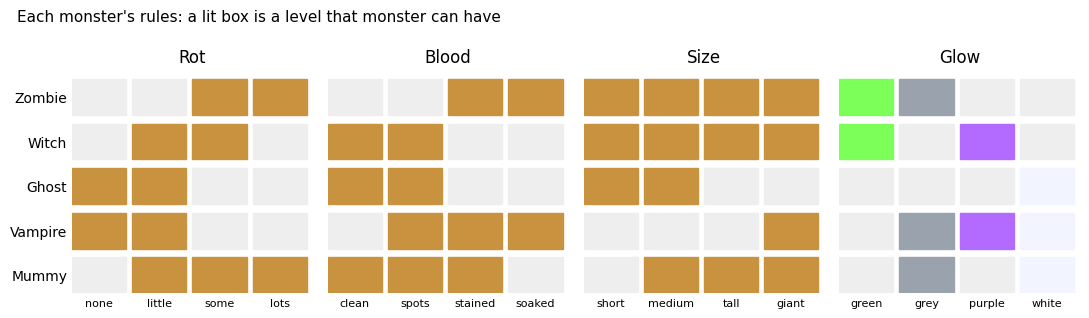

In [5]:
LEVEL_WORDS = {'rot': ['none', 'little', 'some', 'lots'], 'blood': ['clean', 'spots', 'stained', 'soaked'],
               'height': ['short', 'medium', 'tall', 'giant'], 'color': COLORS}
TITLE = {'rot': 'Rot', 'blood': 'Blood', 'height': 'Size', 'color': 'Glow'}
GLOW = {'green': '#7dff5a', 'grey': '#9aa3ad', 'purple': '#b36bff', 'white': '#f2f4ff'}

fig, axes = plt.subplots(1, 4, figsize=(11, 3.2), sharey=True)
for ax, q in zip(axes, QUESTIONS):
    for i, c in enumerate(CLASSES):
        for lv in range(4):
            on = lv in RULES[c][q]
            face = (GLOW[COLORS[lv]] if q == 'color' else '#c8923f') if on else '#eeeeee'
            ax.add_patch(plt.Rectangle((lv, 4 - i), 0.9, 0.8, color=face))
    ax.set_xlim(0, 4); ax.set_ylim(0, 5); ax.set_xticks(np.arange(4) + 0.45); ax.set_xticklabels(LEVEL_WORDS[q], fontsize=8)
    ax.set_title(TITLE[q]); ax.tick_params(length=0); ax.spines[:].set_visible(False)
axes[0].set_yticks(np.arange(5) + 0.4); axes[0].set_yticklabels(CLASSES[::-1])
fig.suptitle('Each monster\'s rules: a lit box is a level that monster can have', x=0.02, ha='left', fontsize=11)
fig.tight_layout(); fig.savefig(FIGS / 'rule_board.png', dpi=150); plt.show()

## 4. Which question first? (the Owl's advice)

The best first question is the one that turns over the most cards on average. The game's Owl uses the same idea during play: it counts, for each unasked question, how many of the cards still up it would turn over.

In [6]:
L = levels(game, CUTS); ok = follows
avg_down = {}
for q in QUESTIONS:
    down = [sum(L[q][i] not in RULES[c][q] for c in CLASSES) for i in np.where(ok)[0]]
    avg_down[q] = np.mean(down)
pd.Series(avg_down, name='cards turned over by this first question').sort_values(ascending=False).round(2)

color     2.48
rot       2.29
blood     2.18
height    1.46
Name: cards turned over by this first question, dtype: float64

## 5. Export for the game

In [7]:
q_meta = {'rot': 'face', 'blood': 'hands', 'height': 'shadow', 'color': 'eyes'}
tells = {
    'questions': QUESTIONS, 'field': {q: FIELD.get(q, 'color') for q in QUESTIONS}, 'cuts': CUTS, 'colors': COLORS,
    'levels': LEVEL_WORDS, 'where': q_meta, 'rules': RULES, 'min_share': EPS,
    'stats': {k: round(float(v), 4) for k, v in stats.items()},
}
(WEB / 'tells.json').write_text(json.dumps(tells, indent=1))
print(json.dumps(RULES, indent=1))

{
 "Zombie": {
  "rot": [
   2,
   3
  ],
  "blood": [
   2,
   3
  ],
  "height": [
   0,
   1,
   2,
   3
  ],
  "color": [
   0,
   1
  ]
 },
 "Witch": {
  "rot": [
   1,
   2
  ],
  "blood": [
   0,
   1
  ],
  "height": [
   0,
   1,
   2,
   3
  ],
  "color": [
   0,
   2
  ]
 },
 "Ghost": {
  "rot": [
   0,
   1
  ],
  "blood": [
   0,
   1
  ],
  "height": [
   0,
   1
  ],
  "color": [
   3
  ]
 },
 "Vampire": {
  "rot": [
   0,
   1
  ],
  "blood": [
   1,
   2,
   3
  ],
  "height": [
   3
  ],
  "color": [
   1,
   2,
   3
  ]
 },
 "Mummy": {
  "rot": [
   1,
   2,
   3
  ],
  "blood": [
   0,
   1,
   2
  ],
  "height": [
   1,
   2,
   3
  ],
  "color": [
   1,
   3
  ]
 }
}


## Result

Four questions with four levels each are enough. Most held-out monsters follow their monster's rules, and for those the answers usually leave a single card. The rest (monsters that break a rule) become the game's **tricksters**, a rare surprise from night 3, and a wrong guess on one costs nothing.

The neural network from notebook 03 is still used: when two cards are left after all four questions, the Owl uses it to say which one is more likely.